In [1]:
# =============================================================================
# Cell 0 (STANDARD): Setup & activate last run
# =============================================================================
import importlib
import numpy as np
import infra
import embeddings
importlib.reload(infra)
importlib.reload(embeddings)

infra.activate_last_run(echo=False)
RP, cfg, ENCODER_SPEC = infra.load_embeddings_run(strict=True)

SEED = 42
np.random.seed(SEED)

YEAR         = int(cfg.get("year", 2025))
ONET_VERSION = str(cfg.get("onet_version", "30_0"))
ENCODER_NAME = str(cfg.get("encoder_name", "")).strip()

print("PROJECT_ROOT :", infra.PROJECT_ROOT)
print("RUNS_ROOT    :", infra.RUNS_ROOT)
print("RUN_TAG      :", infra.RUN_TAG)
print("RUN_DIR      :", infra.RUN_DIR)
print("Exports      :", RP.exports)
print("Figures      :", RP.figures)
print("Cache (run)  :", RP.cache)
print("Cache (glob) :", infra.GLOBAL_CACHE_ROOT)
print("YEAR         :", YEAR)
print("ONET_VERSION :", ONET_VERSION)
print("ENCODER_NAME :", ENCODER_NAME)
print("ENCODER_ID   :", ENCODER_SPEC.embedder_id())
print("SEED         :", SEED)



PROJECT_ROOT : /home/joc/code/geometry-of-work
RUNS_ROOT    : /home/joc/code/geometry-of-work/out/runs
RUN_TAG      : embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
RUN_DIR      : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1
Exports      : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports
Figures      : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures
Cache (run)  : /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/cache
Cache (glob) : /home/joc/code/geometry-of-work/out/_cache
YEAR         : 2025
ONET_VERSION : 30_1
ENCODER_NAME : openai-3-large
ENCODER_ID   : openai:text-embedding-3-large?dim=3072
SEED         : 42


In [2]:
# =============================================================================
# Cell 1: Plotting helpers — polar frame and axis utilities
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt

GG_GREY = {
    "grey20": "0.2",
    "grey50": "0.5",
    "grey60": "0.6",
    "grey70": "0.7",
    "grey90": "0.9",
    "white":  "1.0",
    "black":  "0.0",
}

def minimal_axes(ax):
    """Remove ticks and spines for a clean polar canvas."""
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)

def add_polar_frame(ax,
                    radii=(0.2, 0.4, 0.6, 0.8, 1.0),
                    circle_color="#333333",  circle_lw=0.3,  outer_lw=0.5,
                    spoke_color="#333333",   spoke_lw=0.4,
                    label_color="#333333",   label_fs=9,     label_r=1.06,
                    degree_labels=("0°","45°","90°","135°","180°","225°","270°","315°"),
                    cross_color="#B3B3B3",   cross_lw=0.3,
                    draw_labels=True, draw_spokes=True, draw_cross=True):
    """Draw concentric circles, spokes and degree labels on a Cartesian axis."""
    theta = np.linspace(0, 2 * np.pi, 400)
    for r in radii:
        lw = outer_lw if np.isclose(r, max(radii)) else circle_lw
        ax.plot(r * np.cos(theta), r * np.sin(theta),
                color=circle_color, lw=lw, zorder=1)
    angles = np.arange(0, 2 * np.pi, np.pi / 4)
    if draw_spokes:
        for a in angles:
            ax.plot([0, np.cos(a)], [0, np.sin(a)],
                    color=spoke_color, lw=spoke_lw, zorder=1)
    if draw_labels:
        for a, lab in zip(angles, degree_labels):
            ax.text(label_r * np.cos(a), label_r * np.sin(a), lab,
                    ha="center", va="center", fontsize=label_fs,
                    color=label_color, zorder=2)
    if draw_cross:
        ax.plot([-1, 1], [0, 0], color=cross_color, lw=cross_lw, zorder=1)
        ax.plot([0, 0], [-1, 1], color=cross_color, lw=cross_lw, zorder=1)




In [3]:
# =============================================================================
# Cell 2: Load task and occupation embeddings from current run
# =============================================================================
import pandas as pd
import numpy as np

# Paths from active run
TASK_EMBEDDINGS_PATH = RP.exports / "task_embeddings_polar_scaled.csv"
OCC_EMBEDDINGS_PATH  = RP.exports / "occupation_embeddings_polar_scaled.csv"

shock = pd.read_csv(TASK_EMBEDDINGS_PATH)
jobs  = pd.read_csv(OCC_EMBEDDINGS_PATH)

def ensure_cart(df, name="df"):
    """Add x_cart / y_cart columns from (xi, chi) if not already present."""
    if {"x_cart", "y_cart"}.issubset(df.columns):
        return df
    if {"xi", "chi"}.issubset(df.columns):
        df = df.copy()
        df["xi"]     = pd.to_numeric(df["xi"],  errors="coerce")
        df["chi"]    = pd.to_numeric(df["chi"], errors="coerce")
        df["x_cart"] = df["chi"] * np.cos(df["xi"])
        df["y_cart"] = df["chi"] * np.sin(df["xi"])
        return df
    raise ValueError(
        f"{name} saknar x_cart/y_cart och xi/chi. Finns: {sorted(df.columns)}")

shock = ensure_cart(shock, "shock")
jobs  = ensure_cart(jobs,  "jobs")

print("shock cols:", [c for c in ["xi","chi","x_cart","y_cart"] if c in shock.columns])
print("jobs  cols:", [c for c in ["onet_code","Job Family","xi","chi","x_cart","y_cart"]
                      if c in jobs.columns])




shock cols: ['xi', 'chi', 'x_cart', 'y_cart']
jobs  cols: ['onet_code', 'Job Family', 'xi', 'chi', 'x_cart', 'y_cart']


In [4]:
# =============================================================================
# Cell 3: Load BLS wages and merge onto occupation embeddings
# =============================================================================
import pandas as pd
import numpy as np
 
# Wage file path via PROJECT_ROOT — no hardcoded strings
WAGE_PATH = infra.PROJECT_ROOT / "data" / "wages" / "national_M2023_dl.xlsx"
 
# Columns: 8=OCC_CODE, 9=OCC_TITLE, 10=TOT_EMP, 22=H_MEDIAN
wages = pd.read_excel(WAGE_PATH, usecols=[8, 9, 11, 22]).copy()
wages.columns = ["OCC_CODE", "OCC_TITLE", "TOT_EMP", "H_MEDIAN"]
wages["OCC_CODE"]  = (wages["OCC_CODE"].astype(str)
                      .str.replace(r"\..*", "", regex=True).str.strip())
wages["H_MEDIAN"]  = pd.to_numeric(wages["H_MEDIAN"], errors="coerce")
wages["TOT_EMP"]   = pd.to_numeric(wages["TOT_EMP"],  errors="coerce")
 
# Normalise OCC_CODE in jobs and merge
jobs = jobs.copy()
jobs["OCC_CODE"] = (jobs["onet_code"].astype(str)
                    .str.replace(r"\..*", "", regex=True).str.strip())
jobs = jobs.merge(wages[["OCC_CODE", "TOT_EMP", "H_MEDIAN"]], on="OCC_CODE", how="left")
 
jobs_wage = jobs.dropna(subset=["H_MEDIAN", "x_cart", "y_cart"]).copy()
 
print(f"jobs: {len(jobs):,}  |  jobs_wage (with H_MEDIAN): {len(jobs_wage):,}")
print(f"H_MEDIAN range: ${jobs_wage['H_MEDIAN'].min():.2f} – ${jobs_wage['H_MEDIAN'].max():.2f}")
missing_fam = jobs_wage["Job Family"].isna().sum()
if missing_fam:
    print(f"  Warning: {missing_fam} rows missing Job Family label")
 

jobs: 878  |  jobs_wage (with H_MEDIAN): 785
H_MEDIAN range: $14.02 – $113.46


Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/wage_viridis_log10.pdf


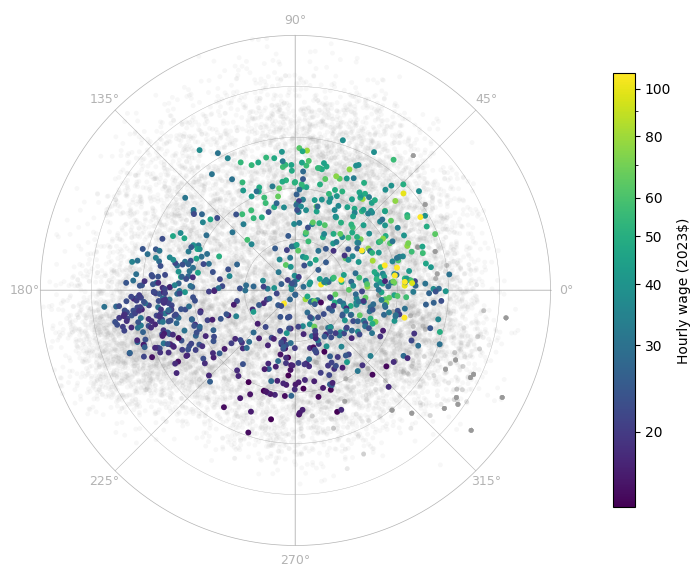

In [5]:
# =============================================================================
# Cell 4: Scatter plot — hourly wages in polar task space (log10 / viridis)
# =============================================================================
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter

plt.close("all")

# Validate required columns
for df_name, df_obj, needed in [
    ("jobs_wage", jobs_wage, {"x_cart", "y_cart", "H_MEDIAN"}),
    ("shock",     shock,     {"x_cart", "y_cart"}),
]:
    missing = sorted(needed - set(df_obj.columns))
    if missing:
        raise ValueError(f"{df_name} saknar kolumner: {missing}")

fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor("white")

add_polar_frame(
    ax,
    circle_color=GG_GREY["grey70"], spoke_color=GG_GREY["grey70"],
    label_color=GG_GREY["grey70"],  cross_color=GG_GREY["grey70"],
    draw_labels=True, label_fs=9, label_r=1.06,
)

# Background task cloud
ax.scatter(shock["x_cart"], shock["y_cart"],
           s=12, alpha=0.08, c=GG_GREY["grey60"], edgecolors="none", zorder=1)

# Wage scatter — log10 normalisation, no clipping
vals      = np.asarray(jobs_wage["H_MEDIAN"], float)
vals_pos  = vals[np.isfinite(vals) & (vals > 0)]
if vals_pos.size < 10:
    raise ValueError("För få positiva H_MEDIAN-värden för log-skala.")

cap_lo = float(np.nanmin(vals_pos))
cap_hi = float(np.nanpercentile(vals_pos, 99))
norm   = mcolors.LogNorm(vmin=cap_lo, vmax=cap_hi, clip=False)

cmap = plt.get_cmap("viridis").copy()
cmap.set_over(cmap(1.0))
cmap.set_under(cmap(0.0))

sc = ax.scatter(jobs_wage["x_cart"], jobs_wage["y_cart"],
                c=vals, cmap=cmap, norm=norm,
                s=18, edgecolors="none", zorder=3)

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
minimal_axes(ax)

cbar = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.06, extend="neither")
cbar.set_label("Hourly wage (2023$)")
ticks = [t for t in [20, 30, 40, 50, 60, 80, 100] if cap_lo <= t <= cap_hi]
cbar.set_ticks(ticks)
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(round(x))}"))
cbar.ax.yaxis.get_offset_text().set_visible(False)

# Save to RP.figures
out_fig = RP.figures / "wage_viridis_log10.pdf"
fig.savefig(out_fig, dpi=600, bbox_inches="tight", facecolor="white")
print("Saved:", out_fig)
plt.show()




In [6]:
# =============================================================================
# Cell 5: Aggregate wages per job family — export CSV and display summary
#
# Maps O*NET codes → Job Family via data/onet/All_Job_Families.csv, then
# computes employment-weighted mean, weighted std, median, p25/p75, and
# occupation count per family. Exports to RP.exports and displays inline.
# =============================================================================
import pandas as pd
import numpy as np
from IPython.display import display
 
JOB_FAMILY_PATH = infra.PROJECT_ROOT / "data" / "onet" / "All_Job_Families.csv"
 
# Load mapping: Code -> Job Family
# Kolumnnamnen har inbäddade enkla citattecken: 'Code', 'Job Family'
jf_map = pd.read_csv(JOB_FAMILY_PATH)
jf_map.columns = jf_map.columns.str.strip().str.strip("'")
print("All_Job_Families.csv columns:", list(jf_map.columns))
 
jf_map["_code"]       = jf_map["Code"].astype(str).str.strip()
jf_map["_job_family"] = jf_map["Job Family"].astype(str).str.strip()
 
# Merge onto jobs; use a private column name to avoid collision with any
# existing 'Job Family' column in the occupations file
jw = jobs.copy()
# Drop any pre-existing Job Family column to avoid _x/_y suffixing
if "Job Family" in jw.columns:
    jw = jw.drop(columns=["Job Family"])
jw["_code"] = jw["onet_code"].astype(str).str.strip()
jw = jw.merge(jf_map[["_code", "_job_family"]], on="_code", how="left")
jw = jw.rename(columns={"_job_family": "Job Family"})
 
n_missing = jw["Job Family"].isna().sum()
if n_missing:
    print(f"  Warning: {n_missing}/{len(jw)} occupations could not be mapped "
          f"to a Job Family — they will be excluded from aggregation.")
 
# Keep rows with wage, coordinates and family label
jw = jw.dropna(subset=["H_MEDIAN", "x_cart", "y_cart", "Job Family"]).copy()
 
# Employment weight — TOT_EMP from BLS merge (Cell 3)
jw["_weight"] = pd.to_numeric(jw["TOT_EMP"], errors="coerce").fillna(0.0)
jw.loc[jw["_weight"] <= 0, "_weight"] = 1.0   # fallback for zero/missing rows
 
print(f"\nOccupations used in aggregation: {len(jw):,}")
 
# Weighted statistics helpers
def _wmean(g):
    return float(np.average(g["H_MEDIAN"], weights=g["_weight"]))
 
def _wstd(g):
    mu  = np.average(g["H_MEDIAN"], weights=g["_weight"])
    var = np.average((g["H_MEDIAN"] - mu) ** 2, weights=g["_weight"])
    return float(np.sqrt(var))
 
agg = (
    jw.groupby("Job Family", sort=True)
    .apply(lambda g: pd.Series({
        "wage_mean_weighted": _wmean(g),
        "wage_std_weighted":  _wstd(g),
        "wage_median":        float(g["H_MEDIAN"].median()),
        "wage_p25":           float(g["H_MEDIAN"].quantile(0.25)),
        "wage_p75":           float(g["H_MEDIAN"].quantile(0.75)),
        "n_occupations":      int(len(g)),
        "tot_emp":            float(g["_weight"].sum()),
    }), include_groups=False)
    .reset_index()
    .rename(columns={"Job Family": "job_family"})
    .sort_values("wage_mean_weighted", ascending=False)
    .reset_index(drop=True)
)
 
# Relative wage — normalised to employment-weighted grand mean
# (matches the wage_rel_to_base format expected by gts_core.load_job_families)
grand_mean = float(np.average(agg["wage_mean_weighted"], weights=agg["tot_emp"]))
agg["wage_rel_to_base"] = agg["wage_mean_weighted"] / grand_mean
 
# Export
out_csv = RP.exports / "wage_per_job_family.csv"
agg.to_csv(out_csv, index=False, float_format="%.4f")
print(f"Saved: {out_csv}  ({len(agg)} job families)")
print(f"Grand mean hourly wage: ${grand_mean:.2f}  "
      f"(employment-weighted, TOT_EMP)\n")
 
# Display
display_cols = ["job_family", "wage_mean_weighted", "wage_std_weighted",
                "wage_median", "wage_rel_to_base", "n_occupations"]
display(
    agg[display_cols]
    .style
    .format({
        "wage_mean_weighted": "${:.2f}",
        "wage_std_weighted":  "${:.2f}",
        "wage_median":        "${:.2f}",
        "wage_rel_to_base":   "{:.3f}",
        "n_occupations":      "{:.0f}",
    })
    .bar(subset=["wage_mean_weighted"], color="#4878cf", vmin=0)
    .set_caption("Hourly wages by job family — employment-weighted (TOT_EMP)")
)

All_Job_Families.csv columns: ['Code', 'Occupation', 'Job Family']

Occupations used in aggregation: 785
Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/wage_per_job_family.csv  (22 job families)
Grand mean hourly wage: $32.44  (employment-weighted, TOT_EMP)



,job_family,wage_mean_weighted,wage_std_weighted,wage_median,wage_rel_to_base,n_occupations
0,Management,$61.02,$13.97,$56.24,1.881,51
1,Legal,$55.24,$19.69,$34.39,1.703,7
2,Computer and Mathematical,$51.39,$9.97,$50.44,1.584,30
3,Architecture and Engineering,$47.89,$7.04,$47.78,1.476,51
4,Healthcare Practitioners and Technical,$47.41,$22.14,$41.73,1.462,64
5,"Life, Physical, and Social Science",$38.87,$9.17,$39.33,1.198,57
6,Business and Financial Operations,$37.32,$4.05,$36.38,1.151,38
7,"Arts, Design, Entertainment, Sports, and Media",$32.34,$8.15,$30.07,0.997,34
8,Construction and Extraction,$28.51,$5.47,$24.92,0.879,59
9,Protective Service,$28.22,$9.51,$26.24,0.870,25


In [7]:
# =============================================================================
# Cell 6: Load RLE per occupation via onet.education module
#
# Uses the onet-module API (same pattern as onet.build_df_tasks) to read
# "Education, Training, and Experience" and compute frequency-weighted mean
# Required Level of Education (scale 1–12) per O*NET occupation code.
# Requires db from Cell 0 / the active run.
# =============================================================================
import importlib
import onet
import onet.education as edu
importlib.reload(edu)
 
db      = onet.get_db(version=ONET_VERSION)
occ_meta = onet.load_occ_meta(db)
edu_occ  = edu.rle_by_occupation(db)
 
print(f"Occupations with RLE: {len(edu_occ):,}")
print(f"RLE_mean range: {edu_occ['rle_mean'].min():.2f} – {edu_occ['rle_mean'].max():.2f}")
print(edu_occ.head())


Occupations with RLE: 878
RLE_mean range: 1.35 – 11.92
    onet_code  rle_mean  rle_weight_sum
0  11-1011.00    7.2413           100.0
1  11-1011.03    7.7037           100.0
2  11-1021.00    3.6732           100.0
3  11-2011.00    5.2070           100.0
4  11-2021.00    6.6805           100.0


In [8]:
# =============================================================================
# Cell 7: Merge RLE onto occupation embeddings
#
# Reads occupation embeddings fresh from RP.exports and joins rle_mean
# from Cell 6. Independent of the wage merge in Cell 3.
# =============================================================================
import pandas as pd
import numpy as np
 
jobs_edu = pd.read_csv(RP.exports / "occupation_embeddings_polar_scaled.csv")
jobs_edu = ensure_cart(jobs_edu, "jobs_edu")
jobs_edu = jobs_edu.merge(edu_occ[["onet_code", "rle_mean"]], on="onet_code", how="left")
 
n_missing = jobs_edu["rle_mean"].isna().sum()
print(f"jobs_edu: {len(jobs_edu):,}  |  with rle_mean: {jobs_edu['rle_mean'].notna().sum():,}"
      + (f"  |  missing: {n_missing}" if n_missing else ""))
 
 


jobs_edu: 878  |  with rle_mean: 878


Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/education_rle_mean.pdf


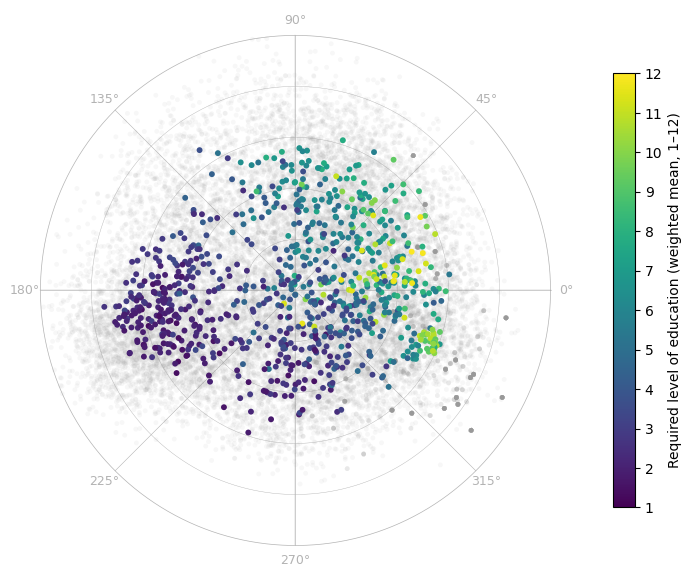

In [9]:
# =============================================================================
# Cell 9: Scatter plot — Required Level of Education in polar task space
#
# Linear colour scale 1–12 (viridis), consistent palette with wage figure.
# Saved to RP.figures.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter
 
plt.close("all")
 
for df_name, df_obj, needed in [
    ("jobs_edu", jobs_edu, {"x_cart", "y_cart", "rle_mean"}),
    ("shock",    shock,    {"x_cart", "y_cart"}),
]:
    miss = sorted(needed - set(df_obj.columns))
    if miss:
        raise ValueError(f"{df_name} saknar kolumner: {miss}")
 
fig, ax = plt.subplots(figsize=(8, 8))
fig.patch.set_facecolor("white")
 
add_polar_frame(
    ax,
    circle_color=GG_GREY["grey70"], spoke_color=GG_GREY["grey70"],
    label_color=GG_GREY["grey70"],  cross_color=GG_GREY["grey70"],
    draw_labels=True, label_fs=9, label_r=1.06,
)
ax.scatter(shock["x_cart"], shock["y_cart"],
           s=12, alpha=0.08, c=GG_GREY["grey60"], edgecolors="none", zorder=1)
 
vals = np.asarray(jobs_edu["rle_mean"], float)
mask = np.isfinite(vals)
norm = mcolors.Normalize(vmin=1, vmax=12, clip=False)
cmap = plt.get_cmap("viridis").copy()
 
sc = ax.scatter(jobs_edu.loc[mask, "x_cart"], jobs_edu.loc[mask, "y_cart"],
                c=vals[mask], cmap=cmap, norm=norm,
                s=18, edgecolors="none", zorder=3)
 
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
minimal_axes(ax)
 
cbar = fig.colorbar(sc, ax=ax, fraction=0.035, pad=0.06)
cbar.set_label("Required level of education (weighted mean, 1–12)")
cbar.set_ticks(list(range(1, 13)))
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x)}"))
cbar.ax.yaxis.get_offset_text().set_visible(False)
 
out_fig = RP.figures / "education_rle_mean.pdf"
fig.savefig(out_fig, dpi=600, bbox_inches="tight", facecolor="white")
print("Saved:", out_fig)
plt.show()
 
 


Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/panel_wage_education.pdf


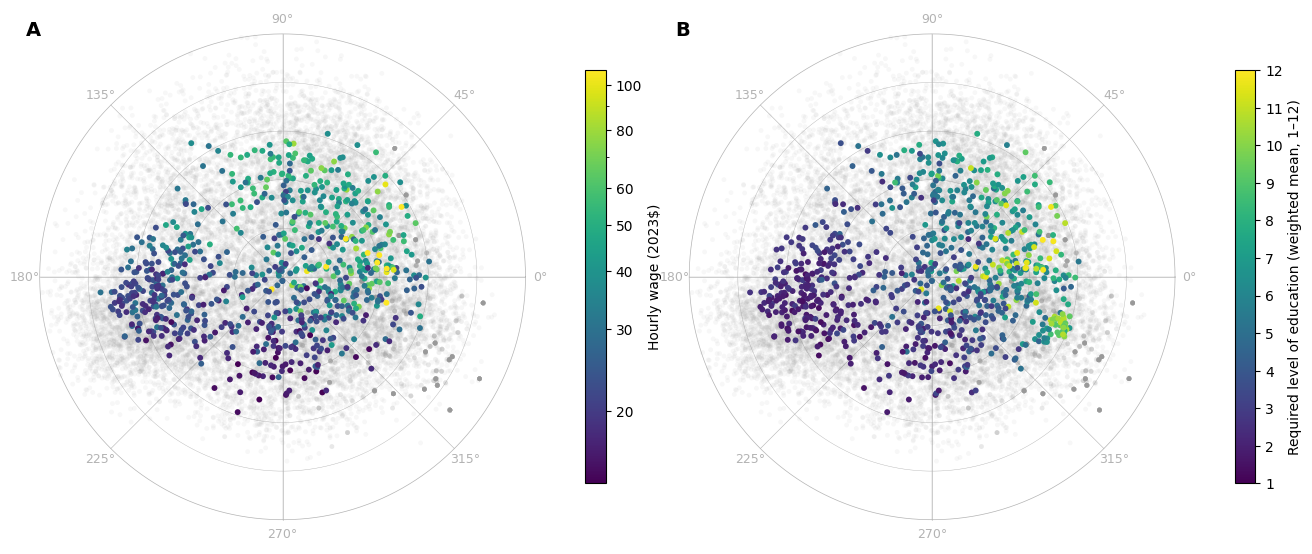

In [10]:
# =============================================================================
# Cell 10: Two-panel figure — wage (A) and education (B) side by side
#
# Combines the single-panel figures into one publication-ready panel figure.
# Saved to RP.figures.
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import FuncFormatter
 
plt.close("all")
 
for df_name, df_obj, needed in [
    ("jobs_wage", jobs_wage, {"x_cart", "y_cart", "H_MEDIAN"}),
    ("jobs_edu",  jobs_edu,  {"x_cart", "y_cart", "rle_mean"}),
    ("shock",     shock,     {"x_cart", "y_cart"}),
]:
    miss = sorted(needed - set(df_obj.columns))
    if miss:
        raise ValueError(f"{df_name} saknar kolumner: {miss}")
 
def base_polar(ax):
    """Apply shared polar frame and background task cloud."""
    add_polar_frame(
        ax,
        circle_color=GG_GREY["grey70"], spoke_color=GG_GREY["grey70"],
        label_color=GG_GREY["grey70"],  cross_color=GG_GREY["grey70"],
        draw_labels=True, label_fs=9, label_r=1.06,
    )
    ax.scatter(shock["x_cart"], shock["y_cart"],
               s=12, alpha=0.08, c=GG_GREY["grey60"], edgecolors="none", zorder=1)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
    minimal_axes(ax)
 
fig, (axA, axB) = plt.subplots(1, 2, figsize=(16, 8))
fig.patch.set_facecolor("white")
 
# Panel A: wage (log scale)
base_polar(axA)
vals_w   = np.asarray(jobs_wage["H_MEDIAN"], float)
vals_pos = vals_w[np.isfinite(vals_w) & (vals_w > 0)]
cap_lo   = float(np.nanmin(vals_pos))
cap_hi   = float(np.nanpercentile(vals_pos, 99))
norm_w   = mcolors.LogNorm(vmin=cap_lo, vmax=cap_hi, clip=False)
cmap_w   = plt.get_cmap("viridis").copy()
cmap_w.set_over(cmap_w(1.0)); cmap_w.set_under(cmap_w(0.0))
 
scA = axA.scatter(jobs_wage["x_cart"], jobs_wage["y_cart"],
                  c=vals_w, cmap=cmap_w, norm=norm_w,
                  s=18, edgecolors="none", zorder=3)
cbarA = fig.colorbar(scA, ax=axA, fraction=0.035, pad=0.06, extend="neither")
cbarA.set_label("Hourly wage (2023$)")
ticksA = [t for t in [20, 30, 40, 50, 60, 80, 100] if cap_lo <= t <= cap_hi]
cbarA.set_ticks(ticksA)
cbarA.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(round(x))}"))
cbarA.ax.yaxis.get_offset_text().set_visible(False)
axA.text(0.02, 0.98, "A", transform=axA.transAxes,
         va="top", ha="left", fontsize=14, fontweight="bold")
 
# Panel B: education (linear 1–12)
base_polar(axB)
vals_e = np.asarray(jobs_edu["rle_mean"], float)
mask_e = np.isfinite(vals_e)
norm_e = mcolors.Normalize(vmin=1, vmax=12, clip=False)
cmap_e = plt.get_cmap("viridis").copy()
 
scB = axB.scatter(jobs_edu.loc[mask_e, "x_cart"], jobs_edu.loc[mask_e, "y_cart"],
                  c=vals_e[mask_e], cmap=cmap_e, norm=norm_e,
                  s=18, edgecolors="none", zorder=3)
cbarB = fig.colorbar(scB, ax=axB, fraction=0.035, pad=0.06)
cbarB.set_label("Required level of education (weighted mean, 1–12)")
cbarB.set_ticks(list(range(1, 13)))
cbarB.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x)}"))
cbarB.ax.yaxis.get_offset_text().set_visible(False)
axB.text(0.02, 0.98, "B", transform=axB.transAxes,
         va="top", ha="left", fontsize=14, fontweight="bold")
 
fig.subplots_adjust(wspace=0.10)
out_fig = RP.figures / "panel_wage_education.pdf"
fig.savefig(out_fig, dpi=600, bbox_inches="tight", facecolor="white")
print("Saved:", out_fig)
plt.show()
 
 


In [11]:
# =============================================================================
# Cell 11: Aggregate RLE per job family — export rle_by_job_family.csv
#
# Uses edu.rle_by_job_family() with occ_meta (contains Job Family + TOT_EMP)
# to compute employment-weighted mean RLE per family. Exports to RP.exports
# in the format expected by gts_core.init(): columns Job Family, rle_mean_family.
# =============================================================================
import pandas as pd
 
# occ_meta needs Job Family — merge from jf_map if not already present
_occ = occ_meta.copy()
_occ["_code"] = _occ["onet_code"].astype(str).str.strip()
if "Job Family" not in _occ.columns:
    _occ = _occ.merge(
        jf_map[["_code", "_job_family"]].rename(columns={"_job_family": "Job Family"}),
        on="_code", how="left")
 
# Attach TOT_EMP from wages for employment weighting
if "TOT_EMP" not in _occ.columns and "TOT_EMP" in wages.columns:
    _occ["OCC_CODE"] = _occ["onet_code"].astype(str).str.replace(r"\..*", "", regex=True).str.strip()
    _occ = _occ.merge(wages[["OCC_CODE", "TOT_EMP"]], on="OCC_CODE", how="left")
 
rle_agg = edu.rle_by_job_family(db, _occ, weight_col="TOT_EMP")
 
out_csv = RP.exports / "rle_by_job_family.csv"
rle_agg.to_csv(out_csv, index=False, float_format="%.4f")
print(f"Saved: {out_csv}  ({len(rle_agg)} job families, employment-weighted)")
print(f"RLE range: {rle_agg['rle_mean_family'].min():.2f} – "
      f"{rle_agg['rle_mean_family'].max():.2f}\n")
 
display(
    rle_agg
    .style
    .format({
        "rle_mean_family": "{:.2f}",
        "rle_std_family":  "{:.2f}",
        "n_occupations":   "{:.0f}",
    })
    .bar(subset=["rle_mean_family"], color="#4878cf", vmin=0)
    .set_caption("Required Level of Education by job family — employment-weighted (TOT_EMP)")
)

Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/rle_by_job_family.csv  (22 job families, employment-weighted)
RLE range: 1.96 – 8.85



,Job Family,rle_mean_family,rle_std_family,n_occupations
0,Legal,8.85,2.65,7
1,"Life, Physical, and Social Science",7.44,2.03,57
2,Healthcare Practitioners and Technical,7.10,2.12,82
3,Educational Instruction and Library,6.63,1.54,61
4,Community and Social Service,6.49,0.85,14
5,Architecture and Engineering,6.24,1.06,51
6,Computer and Mathematical,5.69,0.75,30
7,Business and Financial Operations,5.66,0.88,43
8,Management,5.43,1.36,52
9,"Arts, Design, Entertainment, Sports, and Media",5.18,1.00,37


Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/correlation_education_wage.pdf


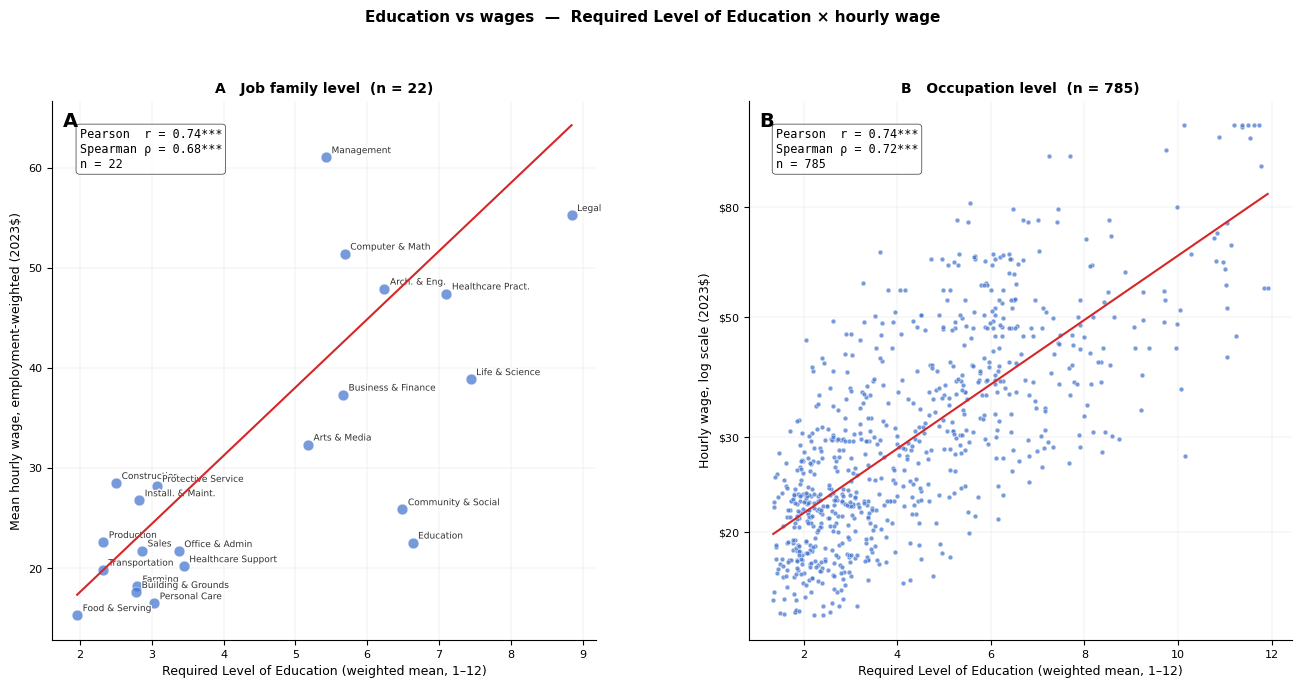

In [12]:
# =============================================================================
# Cell 12: Correlation — Required Level of Education vs hourly wage
#
# Two-panel scatter with OLS regression line and Pearson/Spearman coefficients.
# Panel A: per job family (22 points, labelled, employment-weighted regression).
# Panel B: per occupation (~800 points, density-shaded).
# Saved to RP.figures.
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy import stats
from gts_plot import SHORT
 
plt.close("all")
 
# ── Build per-family dataset ──────────────────────────────────────────────────
fam_corr = agg.merge(
    rle_agg[["Job Family", "rle_mean_family"]],
    left_on="job_family", right_on="Job Family", how="inner"
).dropna(subset=["wage_mean_weighted", "rle_mean_family"])
 
# ── Build per-occupation dataset ──────────────────────────────────────────────
occ_corr = jobs_wage.merge(
    edu_occ[["onet_code", "rle_mean"]], on="onet_code", how="inner"
).dropna(subset=["H_MEDIAN", "rle_mean"])
 
# ── Helper: annotated scatter panel ──────────────────────────────────────────
def _scatter_panel(ax, x, y, weights=None, labels=None,
                   xlabel="", ylabel="", title="",
                   xlog=False, ylog=False, point_color="#4878cf"):
    """Scatter + WLS regression line + Pearson & Spearman annotations."""
    xi = np.log10(x) if xlog else np.array(x, float)
    yi = np.log10(y) if ylog else np.array(y, float)
    mask = np.isfinite(xi) & np.isfinite(yi)
    xi, yi = xi[mask], yi[mask]
    w = np.array(weights, float)[mask] if weights is not None else np.ones(len(xi))
 
    # Scatter
    ax.scatter(x[mask] if not xlog else xi,
               y[mask] if not ylog else yi,
               s=60 if labels is not None else 12,
               c=point_color, alpha=0.75, edgecolors="white",
               linewidths=0.4, zorder=3)
 
    # WLS regression line
    coeffs = np.polyfit(xi, yi, 1, w=w)
    x_line = np.linspace(xi.min(), xi.max(), 200)
    y_line = np.polyval(coeffs, x_line)
    ax.plot(x_line, y_line, color="#d62728", lw=1.5, zorder=4)
 
    # Pearson + Spearman on log-transformed values
    r_p, p_p = stats.pearsonr(xi, yi)
    r_s, p_s = stats.spearmanr(xi, yi)
 
    def _sig(p):
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        return ""
 
    ax.text(0.05, 0.95,
            f"Pearson  r = {r_p:.2f}{_sig(p_p)}\n"
            f"Spearman ρ = {r_s:.2f}{_sig(p_s)}\n"
            f"n = {mask.sum()}",
            transform=ax.transAxes, va="top", ha="left",
            fontsize=8.5, family="monospace",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8, lw=0.5))
 
    # Labels (job family panel)
    if labels is not None:
        labs = np.array(labels)[mask]
        xp = xi if xlog else np.array(x, float)[mask]
        yp = yi if ylog else np.array(y, float)[mask]
        for lx, ly, lab in zip(xp, yp, labs):
            ax.annotate(
                SHORT.get(lab, lab), (lx, ly),
                fontsize=6.5, color="#333333",
                xytext=(4, 3), textcoords="offset points",
                path_effects=[pe.withStroke(linewidth=2, foreground="white")])
 
    # Axis formatting
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.tick_params(labelsize=8)
    ax.grid(True, lw=0.3, alpha=0.4)
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
 
 
# ── Figure ────────────────────────────────────────────────────────────────────
fig, (axA, axB) = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor("white")
 
# Panel A: job family
_scatter_panel(
    axA,
    x       = fam_corr["rle_mean_family"].values,
    y       = fam_corr["wage_mean_weighted"].values,
    weights = fam_corr["tot_emp"].values,
    labels  = fam_corr["job_family"].values,
    xlabel  = "Required Level of Education (weighted mean, 1–12)",
    ylabel  = "Mean hourly wage, employment-weighted (2023$)",
    title   = "A   Job family level  (n = 22)",
    ylog    = False,
)
axA.text(0.02, 0.98, "A", transform=axA.transAxes,
         va="top", ha="left", fontsize=14, fontweight="bold")
 
# Panel B: occupation (log wage y-axis for readability)
_scatter_panel(
    axB,
    x       = occ_corr["rle_mean"].values,
    y       = occ_corr["H_MEDIAN"].values,
    xlabel  = "Required Level of Education (weighted mean, 1–12)",
    ylabel  = "Hourly wage, log scale (2023$)",
    title   = f"B   Occupation level  (n = {len(occ_corr):,})",
    ylog    = True,
    point_color = "#4878cf",
)
# Relabel y-axis ticks back to dollar values
yticks = [10, 20, 30, 50, 80, 120]
axB.set_yticks([np.log10(t) for t in yticks if occ_corr["H_MEDIAN"].min() <= t <= occ_corr["H_MEDIAN"].max()])
axB.set_yticklabels([f"${t}" for t in yticks if occ_corr["H_MEDIAN"].min() <= t <= occ_corr["H_MEDIAN"].max()])
axB.text(0.02, 0.98, "B", transform=axB.transAxes,
         va="top", ha="left", fontsize=14, fontweight="bold")
 
fig.suptitle("Education vs wages  —  Required Level of Education × hourly wage",
             fontsize=11, fontweight="bold", y=1.01)
fig.subplots_adjust(wspace=0.28)
 
out_fig = RP.figures / "correlation_education_wage.pdf"
fig.savefig(out_fig, dpi=300, bbox_inches="tight", facecolor="white")
print("Saved:", out_fig)
plt.show()

In [13]:
print(jw[["onet_code", "TOT_EMP", "_weight"]].head(10).to_string())
print("TOT_EMP dtype:", jw["TOT_EMP"].dtype)
print("max TOT_EMP:", jw["TOT_EMP"].max())

    onet_code    TOT_EMP    _weight
0  11-1011.00   211230.0   211230.0
1  11-1011.03   211230.0   211230.0
2  11-1021.00  3507810.0  3507810.0
3  11-2011.00    20630.0    20630.0
4  11-2021.00   368940.0   368940.0
5  11-2022.00   575880.0   575880.0
6  11-2033.00    31810.0    31810.0
7  11-3012.00   242520.0   242520.0
8  11-3013.00   131400.0   131400.0
9  11-3013.01   131400.0   131400.0
TOT_EMP dtype: float64
max TOT_EMP: 3684740.0


In [14]:
# =============================================================================
# Cell 13: Pair-level test — task-space distance vs ln(wage) and education
#
# Tests whether geometric proximity in task space predicts socioeconomic
# similarity between occupations, parallel to the capability-similarity test
# in Section 3.2.1 (Test 1).
#
# For all occupation pairs (i,j) with both ln(H_MEDIAN) and rle_mean defined:
#   - Δd_ij  : Euclidean distance between centroids in (x_cart, y_cart)
#   - Δξ_ij  : circular angular distance, min(|ξ_i - ξ_j|, 2π - |ξ_i - ξ_j|)
#   - Δχ_ij  : |χ_i - χ_j|
#   - |Δln w_ij| : absolute difference in log hourly wage
#   - |ΔE_ij|    : absolute difference in RLE
#
# Reports Spearman ρ for each (distance, outcome) pair, plus partial Spearman
# correlations controlling for the other geometric dimension. Employment-
# weighted versions reported as sensitivity check.
# =============================================================================
import numpy as np
import pandas as pd
from scipy import stats
from itertools import combinations

# ── Build the pair-level dataset ──────────────────────────────────────────────
# Use occ_corr from Cell 12: already merged on (H_MEDIAN, rle_mean).
# Need to add xi, chi, TOT_EMP from jobs_wage.
needed_cols = {"onet_code", "xi", "chi", "x_cart", "y_cart", "H_MEDIAN",
               "rle_mean", "TOT_EMP"}
pair_df = (
    occ_corr
    .merge(jobs_wage[["onet_code", "xi", "chi", "TOT_EMP"]],
           on="onet_code", how="left", suffixes=("", "_dup"))
    .dropna(subset=["xi", "chi", "x_cart", "y_cart",
                    "H_MEDIAN", "rle_mean"])
    .reset_index(drop=True)
)

# log wage; RLE is already on its 1–12 scale
pair_df["ln_wage"] = np.log(pair_df["H_MEDIAN"])

n_occ = len(pair_df)
n_pairs = n_occ * (n_occ - 1) // 2
print(f"Occupations with complete data: {n_occ:,}")
print(f"Pairs: {n_pairs:,}")

# ── Vectorized pairwise differences ───────────────────────────────────────────
xi  = pair_df["xi"].to_numpy()
chi = pair_df["chi"].to_numpy()
x   = pair_df["x_cart"].to_numpy()
y   = pair_df["y_cart"].to_numpy()
lnw = pair_df["ln_wage"].to_numpy()
rle = pair_df["rle_mean"].to_numpy()
emp = pair_df["TOT_EMP"].to_numpy()

iu = np.triu_indices(n_occ, k=1)
i_idx, j_idx = iu

# Geometric distances
d_eucl = np.hypot(x[i_idx] - x[j_idx], y[i_idx] - y[j_idx])
d_xi_raw = np.abs(xi[i_idx] - xi[j_idx])
d_xi = np.minimum(d_xi_raw, 2 * np.pi - d_xi_raw)   # circular
d_chi = np.abs(chi[i_idx] - chi[j_idx])

# Socioeconomic differences
d_lnw = np.abs(lnw[i_idx] - lnw[j_idx])
d_rle = np.abs(rle[i_idx] - rle[j_idx])

# Employment weights for sensitivity (geometric mean of pair employment)
w_pair = np.sqrt(emp[i_idx] * emp[j_idx])
w_pair = np.where(np.isfinite(w_pair) & (w_pair > 0), w_pair, np.nan)

# ── Reporting helpers ─────────────────────────────────────────────────────────
def _sig(p):
    if not np.isfinite(p):  return ""
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

def spearman(a, b):
    """Spearman ρ over finite pairs."""
    m = np.isfinite(a) & np.isfinite(b)
    r, p = stats.spearmanr(a[m], b[m])
    return r, p, int(m.sum())

def partial_spearman(a, b, c):
    """
    Partial Spearman correlation of a and b controlling for c.
    Uses rank residualization: rank-transform all three, residualize
    rank(a) and rank(b) against rank(c) via OLS, then Pearson on residuals.
    """
    m = np.isfinite(a) & np.isfinite(b) & np.isfinite(c)
    ar = stats.rankdata(a[m])
    br = stats.rankdata(b[m])
    cr = stats.rankdata(c[m])
    # Residualize via OLS on c-rank
    def resid(z, ctrl):
        beta = np.cov(z, ctrl, ddof=1)[0, 1] / np.var(ctrl, ddof=1)
        return z - beta * ctrl - (z.mean() - beta * ctrl.mean())
    ar_res = resid(ar, cr)
    br_res = resid(br, cr)
    r, p = stats.pearsonr(ar_res, br_res)
    return r, p, int(m.sum())

def weighted_spearman(a, b, w):
    """
    Weighted Spearman: Pearson correlation on rank-transformed values
    with weights. Uses weighted Pearson formula on ranks.
    """
    m = np.isfinite(a) & np.isfinite(b) & np.isfinite(w) & (w > 0)
    ar = stats.rankdata(a[m])
    br = stats.rankdata(b[m])
    ww = w[m]
    wsum = ww.sum()
    am = np.sum(ww * ar) / wsum
    bm = np.sum(ww * br) / wsum
    cov = np.sum(ww * (ar - am) * (br - bm)) / wsum
    va  = np.sum(ww * (ar - am) ** 2) / wsum
    vb  = np.sum(ww * (br - bm) ** 2) / wsum
    return cov / np.sqrt(va * vb), int(m.sum())

# ── Run tests ─────────────────────────────────────────────────────────────────
rows = []

# Total Euclidean distance
for label, outcome, arr in [("ln(wage)", d_lnw, d_lnw),
                             ("RLE",      d_rle, d_rle)]:
    r, p, n = spearman(d_eucl, arr)
    rows.append(("Euclidean d", f"|Δ {label}|", r, p, n))

# Angular distance Δξ
for label, arr in [("ln(wage)", d_lnw), ("RLE", d_rle)]:
    r, p, n = spearman(d_xi, arr)
    rows.append(("Angular Δξ (circular)", f"|Δ {label}|", r, p, n))

# Radial distance Δχ
for label, arr in [("ln(wage)", d_lnw), ("RLE", d_rle)]:
    r, p, n = spearman(d_chi, arr)
    rows.append(("Radial Δχ", f"|Δ {label}|", r, p, n))

# Partial: Δξ controlling for Δχ
for label, arr in [("ln(wage)", d_lnw), ("RLE", d_rle)]:
    r, p, n = partial_spearman(d_xi, arr, d_chi)
    rows.append(("Δξ | Δχ (partial)", f"|Δ {label}|", r, p, n))

# Partial: Δχ controlling for Δξ
for label, arr in [("ln(wage)", d_lnw), ("RLE", d_rle)]:
    r, p, n = partial_spearman(d_chi, arr, d_xi)
    rows.append(("Δχ | Δξ (partial)", f"|Δ {label}|", r, p, n))

results = pd.DataFrame(rows, columns=["Distance", "Outcome", "Spearman ρ",
                                       "p-value", "N pairs"])
print("\n── Unweighted Spearman correlations ─────────────────────────────────")
print(results.to_string(index=False,
                        formatters={"Spearman ρ": "{:+.3f}".format,
                                    "p-value":    "{:.2e}".format,
                                    "N pairs":    "{:,}".format}))

# ── Employment-weighted sensitivity ───────────────────────────────────────────
print("\n── Employment-weighted Spearman (sensitivity) ───────────────────────")
weighted_rows = []
for dist_label, dist_arr in [("Euclidean d", d_eucl),
                              ("Angular Δξ", d_xi),
                              ("Radial Δχ",  d_chi)]:
    for out_label, out_arr in [("ln(wage)", d_lnw), ("RLE", d_rle)]:
        r, n = weighted_spearman(dist_arr, out_arr, w_pair)
        weighted_rows.append((dist_label, f"|Δ {out_label}|", r, n))
weighted_df = pd.DataFrame(weighted_rows,
                            columns=["Distance", "Outcome",
                                     "Weighted ρ", "N pairs"])
print(weighted_df.to_string(index=False,
                             formatters={"Weighted ρ": "{:+.3f}".format,
                                         "N pairs":    "{:,}".format}))

# ── Export results ────────────────────────────────────────────────────────────
out_csv = RP.exports / "pair_level_geometry_wage_education.csv"
results.to_csv(out_csv, index=False, float_format="%.6f")
print(f"\nSaved: {out_csv}")

out_csv_w = RP.exports / "pair_level_geometry_wage_education_weighted.csv"
weighted_df.to_csv(out_csv_w, index=False, float_format="%.6f")
print(f"Saved: {out_csv_w}")

Occupations with complete data: 785
Pairs: 307,720

── Unweighted Spearman correlations ─────────────────────────────────
             Distance      Outcome Spearman ρ   p-value N pairs
          Euclidean d |Δ ln(wage)|     +0.277  0.00e+00 307,720
          Euclidean d      |Δ RLE|     +0.464  0.00e+00 307,720
Angular Δξ (circular) |Δ ln(wage)|     +0.301  0.00e+00 307,720
Angular Δξ (circular)      |Δ RLE|     +0.442  0.00e+00 307,720
            Radial Δχ |Δ ln(wage)|     -0.033  5.70e-73 307,720
            Radial Δχ      |Δ RLE|     +0.015  8.40e-17 307,720
    Δξ | Δχ (partial) |Δ ln(wage)|     +0.306  0.00e+00 307,720
    Δξ | Δχ (partial)      |Δ RLE|     +0.443  0.00e+00 307,720
    Δχ | Δξ (partial) |Δ ln(wage)|     -0.065 9.07e-282 307,720
    Δχ | Δξ (partial)      |Δ RLE|     -0.030  5.45e-64 307,720

── Employment-weighted Spearman (sensitivity) ───────────────────────
   Distance      Outcome Weighted ρ N pairs
Euclidean d |Δ ln(wage)|     +0.335 307,720
Euclidean d    

Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/pair_level_wage_edu_vs_dxi.pdf
Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/pair_level_wage_edu_vs_dxi.png
Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/pair_level_wage_edu_vs_dxi__binned.csv


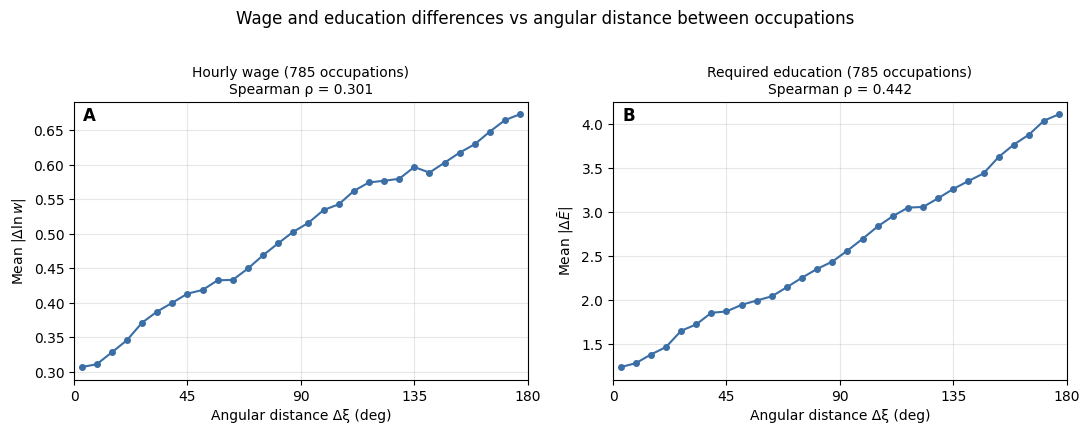

In [15]:
# =============================================================================
# Cell 14: Pair-level figure — angular distance vs |Δ ln(wage)| and |Δ RLE|
#
# Parallel to Figure 4 (Test 1: HC similarity vs Δξ), but with socioeconomic
# outcomes instead of capability similarity. Two panels:
#   A: mean |Δ ln(wage)| binned by Δξ
#   B: mean |Δ E̅|        binned by Δξ
# 30 bins from 0° to 180°.
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

plt.close("all")

# Reuse the vectorized arrays from Cell 13:
#   d_xi (radians, circular), d_lnw, d_rle, n_pairs
# Build a small DataFrame for clarity
pairs = pd.DataFrame({
    "dxi_rad": d_xi,
    "dxi_deg": np.degrees(d_xi),
    "abs_dlnw": d_lnw,
    "abs_dE":   d_rle,
})

# Binning: 30 bins from 0 to π (i.e. 0–180°)
n_bins = 30
edges   = np.linspace(0.0, np.pi, n_bins + 1)
centers = 0.5 * (edges[:-1] + edges[1:])
bin_idx = np.clip(np.digitize(pairs["dxi_rad"], edges) - 1, 0, n_bins - 1)

binned_rows = []
for k in range(n_bins):
    m = bin_idx == k
    binned_rows.append({
        "bin_center_deg": float(np.degrees(centers[k])),
        "mean_abs_dlnw":  float(pairs.loc[m, "abs_dlnw"].mean()) if m.any() else np.nan,
        "mean_abs_dE":    float(pairs.loc[m, "abs_dE"].mean())   if m.any() else np.nan,
        "n_pairs":        int(m.sum()),
    })
binned = pd.DataFrame(binned_rows)

# Pair-level Spearman ρ (positive: larger Δξ → larger absolute difference)
rho_lnw, p_lnw = spearmanr(pairs["dxi_rad"], pairs["abs_dlnw"])
rho_E,   p_E   = spearmanr(pairs["dxi_rad"], pairs["abs_dE"])

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=False)

# Panel A: wage
axA = axes[0]
axA.plot(binned["bin_center_deg"], binned["mean_abs_dlnw"],
         "o-", lw=1.5, color="#3A6EA5", markersize=4)
axA.set_xlabel("Angular distance Δξ (deg)")
axA.set_ylabel(r"Mean $|\Delta \ln w|$")
axA.set_xlim(0, 180)
axA.set_xticks([0, 45, 90, 135, 180])
axA.grid(alpha=0.3)
axA.set_title(f"Hourly wage ({n_occ} occupations)\nSpearman ρ = {rho_lnw:.3f}",
              fontsize=10)
axA.text(0.02, 0.98, "A", transform=axA.transAxes,
         va="top", ha="left", fontsize=12, fontweight="bold")

# Panel B: education
axB = axes[1]
axB.plot(binned["bin_center_deg"], binned["mean_abs_dE"],
         "o-", lw=1.5, color="#3A6EA5", markersize=4)
axB.set_xlabel("Angular distance Δξ (deg)")
axB.set_ylabel(r"Mean $|\Delta \bar{E}|$")
axB.set_xlim(0, 180)
axB.set_xticks([0, 45, 90, 135, 180])
axB.grid(alpha=0.3)
axB.set_title(f"Required education ({n_occ} occupations)\nSpearman ρ = {rho_E:.3f}",
              fontsize=10)
axB.text(0.02, 0.98, "B", transform=axB.transAxes,
         va="top", ha="left", fontsize=12, fontweight="bold")

fig.suptitle(
    "Wage and education differences vs angular distance between occupations",
    fontsize=12, y=1.02,
)
fig.tight_layout()

# Save
out_pdf = RP.figures / "pair_level_wage_edu_vs_dxi.pdf"
out_png = RP.figures / "pair_level_wage_edu_vs_dxi.png"
fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
fig.savefig(out_png, dpi=300, bbox_inches="tight")
print(f"Saved: {out_pdf}")
print(f"Saved: {out_png}")

# Export binned data
out_csv = RP.exports / "pair_level_wage_edu_vs_dxi__binned.csv"
binned.to_csv(out_csv, index=False, float_format="%.6f")
print(f"Saved: {out_csv}")

plt.show()

In [16]:
# =============================================================================
# Cell 15: Occupation-level Mincer regression — geometric position and wages
#
# Standard log-wage regression with polar coordinates as regressors:
#
#     ln(H_MEDIAN_o) = α + β1·cos(ξ_o) + β2·sin(ξ_o) + β3·χ_o
#                      + γ·rle_mean_o + δ·family_FE + ε_o
#
# The cos/sin parameterization respects the circular topology of ξ:
# coefficients β1, β2 jointly define a wage gradient direction in task space
# via atan2(β2, β1), and gradient magnitude via sqrt(β1² + β2²).
#
# Four specifications run separately for ln(H_MEDIAN) and rle_mean as outcomes:
#   (1) geometry only:          ξ + χ
#   (2) with education:         ξ + χ + rle_mean   (wage outcome only)
#   (3) with family FE:         ξ + χ + family dummies
#   (4) full:                   ξ + χ + rle_mean + family dummies (wage only)
#
# Robust standard errors (HC3) reported throughout.
# =============================================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm
 
# ── Build occupation-level regression dataset ─────────────────────────────────
# Use the same merge as Cell 13 but stay at occupation level.
reg_df = (
    jobs_wage[["onet_code", "xi", "chi", "H_MEDIAN", "TOT_EMP", "Job Family"]]
    .merge(edu_occ[["onet_code", "rle_mean"]], on="onet_code", how="inner")
    .dropna(subset=["xi", "chi", "H_MEDIAN", "rle_mean", "Job Family"])
    .reset_index(drop=True)
)
reg_df = reg_df.loc[reg_df["H_MEDIAN"] > 0].copy()
 
reg_df["ln_wage"] = np.log(reg_df["H_MEDIAN"])
reg_df["cos_xi"] = np.cos(reg_df["xi"])
reg_df["sin_xi"] = np.sin(reg_df["xi"])
 
n = len(reg_df)
print(f"Occupations in regression sample: {n:,}")
 
# Family dummies (drop first to avoid collinearity)
family_dummies = pd.get_dummies(reg_df["Job Family"],
                                 prefix="fam", drop_first=True)
n_families = family_dummies.shape[1] + 1
print(f"Job families: {n_families} ({family_dummies.shape[1]} dummies + base)")
 
# ── Helpers ───────────────────────────────────────────────────────────────────
def fit_ols(y, X_cols, label):
    """Fit OLS with HC3 robust SEs, return fitted model."""
    X = sm.add_constant(X_cols.astype(float))
    y = y.astype(float)
    model = sm.OLS(y, X).fit(cov_type="HC3")
    print(f"\n── {label} ─────────────────────────────────────────")
    print(f"   N = {int(model.nobs)}   "
          f"R² = {model.rsquared:.3f}   "
          f"adj R² = {model.rsquared_adj:.3f}")
    return model
 
 
def gradient_direction(model):
    """Compute angular direction and magnitude of the wage gradient."""
    b_cos = model.params.get("cos_xi", np.nan)
    b_sin = model.params.get("sin_xi", np.nan)
    theta_rad = np.arctan2(b_sin, b_cos)
    theta_deg = np.degrees(theta_rad) % 360
    mag = np.hypot(b_cos, b_sin)
    return theta_deg, mag
 
 
def summarize_geometry_coefs(model, label):
    """Print just the geometry coefficients with stars."""
    def sig(p):
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        if p < 0.1:   return "+"
        return ""
 
    geo_names = ["cos_xi", "sin_xi", "chi"]
    if "rle_mean" in model.params.index:
        geo_names.append("rle_mean")
 
    print(f"   {'Variable':<12} {'Coef':>10} {'SE':>10} {'p':>10}")
    for name in geo_names:
        if name in model.params.index:
            b = model.params[name]
            se = model.bse[name]
            p = model.pvalues[name]
            print(f"   {name:<12} {b:>+10.4f} {se:>10.4f} "
                  f"{p:>10.2e} {sig(p)}")
 
 
# ── Wage regressions ──────────────────────────────────────────────────────────
print("\n═══ DEPENDENT VARIABLE: ln(H_MEDIAN) ═══")
 
y_wage = reg_df["ln_wage"]
 
# Spec 1: geometry only
X1 = reg_df[["cos_xi", "sin_xi", "chi"]]
m_wage_1 = fit_ols(y_wage, X1, "Spec 1: geometry only")
summarize_geometry_coefs(m_wage_1, "wage_1")
theta1, mag1 = gradient_direction(m_wage_1)
print(f"   Wage gradient direction: {theta1:.1f}°   magnitude: {mag1:.4f}")
 
# Spec 2: + education
X2 = reg_df[["cos_xi", "sin_xi", "chi", "rle_mean"]]
m_wage_2 = fit_ols(y_wage, X2, "Spec 2: + education")
summarize_geometry_coefs(m_wage_2, "wage_2")
theta2, mag2 = gradient_direction(m_wage_2)
print(f"   Wage gradient direction (conditional): "
      f"{theta2:.1f}°   magnitude: {mag2:.4f}")
 
# Spec 3: + family FE
X3 = pd.concat([reg_df[["cos_xi", "sin_xi", "chi"]], family_dummies], axis=1)
m_wage_3 = fit_ols(y_wage, X3, "Spec 3: + family FE")
summarize_geometry_coefs(m_wage_3, "wage_3")
theta3, mag3 = gradient_direction(m_wage_3)
print(f"   Wage gradient (within family): "
      f"{theta3:.1f}°   magnitude: {mag3:.4f}")
 
# Spec 4: full
X4 = pd.concat([reg_df[["cos_xi", "sin_xi", "chi", "rle_mean"]],
                family_dummies], axis=1)
m_wage_4 = fit_ols(y_wage, X4, "Spec 4: full (geo + edu + family FE)")
summarize_geometry_coefs(m_wage_4, "wage_4")
theta4, mag4 = gradient_direction(m_wage_4)
print(f"   Wage gradient (conditional, within family): "
      f"{theta4:.1f}°   magnitude: {mag4:.4f}")
 
# ── Education regressions ─────────────────────────────────────────────────────
print("\n═══ DEPENDENT VARIABLE: rle_mean ═══")
 
y_edu = reg_df["rle_mean"]
 
# Spec 1e: geometry only
m_edu_1 = fit_ols(y_edu, X1, "Spec 1e: geometry only")
summarize_geometry_coefs(m_edu_1, "edu_1")
theta_e1, mag_e1 = gradient_direction(m_edu_1)
print(f"   Education gradient direction: "
      f"{theta_e1:.1f}°   magnitude: {mag_e1:.4f}")
 
# Spec 3e: + family FE
m_edu_3 = fit_ols(y_edu, X3, "Spec 3e: + family FE")
summarize_geometry_coefs(m_edu_3, "edu_3")
theta_e3, mag_e3 = gradient_direction(m_edu_3)
print(f"   Education gradient (within family): "
      f"{theta_e3:.1f}°   magnitude: {mag_e3:.4f}")
 
# ── Export summary table ──────────────────────────────────────────────────────
def extract_summary(model, spec_label, outcome):
    """Extract key statistics for the summary table."""
    rows = []
    for name in ["cos_xi", "sin_xi", "chi", "rle_mean"]:
        if name in model.params.index:
            rows.append({
                "outcome": outcome,
                "spec": spec_label,
                "variable": name,
                "coef": model.params[name],
                "se": model.bse[name],
                "t": model.tvalues[name],
                "p": model.pvalues[name],
                "ci_low": model.conf_int()[0][name],
                "ci_high": model.conf_int()[1][name],
            })
    rows.append({
        "outcome": outcome, "spec": spec_label, "variable": "_summary_",
        "coef": np.nan, "se": np.nan, "t": np.nan, "p": np.nan,
        "ci_low": model.nobs, "ci_high": model.rsquared,
    })
    return rows
 
all_rows = []
for m, spec, out in [
    (m_wage_1, "geometry_only",       "ln_wage"),
    (m_wage_2, "with_education",      "ln_wage"),
    (m_wage_3, "with_family_FE",      "ln_wage"),
    (m_wage_4, "full",                "ln_wage"),
    (m_edu_1,  "geometry_only",       "rle_mean"),
    (m_edu_3,  "with_family_FE",      "rle_mean"),
]:
    all_rows.extend(extract_summary(m, spec, out))
 
summary_df = pd.DataFrame(all_rows)
out_csv = RP.exports / "mincer_geometric_wage_education.csv"
summary_df.to_csv(out_csv, index=False, float_format="%.6f")
print(f"\nSaved: {out_csv}")

Occupations in regression sample: 785
Job families: 22 (21 dummies + base)

═══ DEPENDENT VARIABLE: ln(H_MEDIAN) ═══

── Spec 1: geometry only ─────────────────────────────────────────
   N = 785   R² = 0.492   adj R² = 0.490
   Variable           Coef         SE          p
   cos_xi          +0.2119     0.0174   4.37e-34 ***
   sin_xi          +0.3886     0.0182  1.08e-101 ***
   chi             -0.0455     0.0898   6.13e-01 
   Wage gradient direction: 61.4°   magnitude: 0.4426

── Spec 2: + education ─────────────────────────────────────────
   N = 785   R² = 0.623   adj R² = 0.621
   Variable           Coef         SE          p
   cos_xi          -0.0025     0.0226   9.13e-01 
   sin_xi          +0.2303     0.0209   3.27e-28 ***
   chi             -0.1648     0.0721   2.22e-02 *
   rle_mean        +0.1080     0.0089   4.13e-34 ***
   Wage gradient direction (conditional): 90.6°   magnitude: 0.2303

── Spec 3: + family FE ─────────────────────────────────────────
   N = 785   R² = 

Occupations per sector:
sector
E     125
NE    101
N      92
NW     44
W     200
SW     67
S      78
SE     78
Name: count, dtype: int64

── χ effect on ln(wage) by angular sector ─────────────────────────
Sector    Center     N   β_χ (uncond)     β_χ (cond)    β_rle
──────────────────────────────────────────────────────────────────────
E             0°   125     -0.151         -0.834***    +0.125
NE           45°   101     +0.812***      +0.103       +0.084
N            90°    92     +0.930***      +0.648**     +0.080
NW          135°    44     +0.275         +0.212       +0.123
W           180°   200     -0.280*        -0.021       +0.105
SW          225°    67     -0.803*        -0.098       +0.143
S           270°    78     -1.044***      -0.834***    +0.055
SE          315°    78     -1.177**       -1.130***    +0.128

Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/mincer_chi_by_sector.pdf
Saved: /home/jo

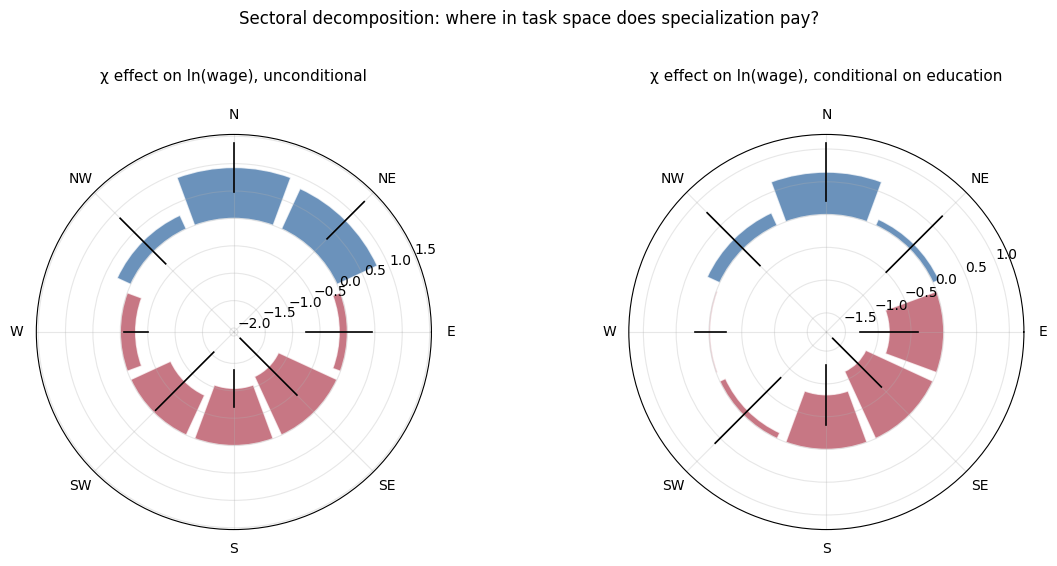

In [17]:
# =============================================================================
# Cell 16: Sectoral analysis of χ effect on wages within angular direction
#
# The negative β_χ in Spec 2 (= −0.165, p = 0.022) is an average across all
# angular directions. The framework predicts that radial specialization should
# manifest as higher capability intensity (P2), and capability intensity should
# in turn translate into higher wages — but only in directions where
# capabilities are highly compensated to begin with.
#
# This cell decomposes the χ effect by angular sector. We split occupations
# into 8 sectors of 45° and re-estimate the wage regression within each:
#
#     ln(H_MEDIAN) = α_s + β_χ_s · χ + γ_s · rle_mean + ε   (within sector s)
#
# The cos/sin terms are dropped within sector since angular variation is small
# inside a 45° wedge. β_χ_s is the sector-specific χ coefficient: positive
# where specialization is rewarded, negative where it is not.
# =============================================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ── Define angular sectors ────────────────────────────────────────────────────
# 8 sectors of 45° each, centered on the cardinal/intercardinal directions:
# sector 0: 337.5°–22.5° (E),  sector 1: 22.5°–67.5° (NE), ...
sector_width = np.pi / 4   # 45°
sector_centers_deg = np.array([0, 45, 90, 135, 180, 225, 270, 315])
sector_centers_rad = np.deg2rad(sector_centers_deg)
sector_labels = ["E", "NE", "N", "NW", "W", "SW", "S", "SE"]


def assign_sector(xi):
    """Assign each ξ to one of 8 sectors. Sector k spans
    [center_k - π/8, center_k + π/8) mod 2π."""
    shifted = np.mod(xi + sector_width / 2, 2 * np.pi)
    return (shifted // sector_width).astype(int)


reg_df["sector_idx"] = assign_sector(reg_df["xi"].to_numpy())
reg_df["sector"] = reg_df["sector_idx"].map(dict(enumerate(sector_labels)))

print("Occupations per sector:")
print(reg_df["sector"].value_counts().reindex(sector_labels))


# ── Estimate χ effect within each sector ─────────────────────────────────────
def estimate_within_sector(df_sec, with_education=True):
    """Estimate ln(wage) ~ χ (+ rle_mean) within a single sector."""
    if len(df_sec) < 15:
        return None
    cols = ["chi"] + (["rle_mean"] if with_education else [])
    X = sm.add_constant(df_sec[cols].astype(float))
    y = df_sec["ln_wage"].astype(float)
    return sm.OLS(y, X).fit(cov_type="HC3")


rows = []
for sec_idx, sec_label in enumerate(sector_labels):
    df_sec = reg_df.loc[reg_df["sector_idx"] == sec_idx]
    n = len(df_sec)

    # Two specifications: chi only, and chi + education
    m1 = estimate_within_sector(df_sec, with_education=False)
    m2 = estimate_within_sector(df_sec, with_education=True)

    row = {
        "sector": sec_label,
        "center_deg": sector_centers_deg[sec_idx],
        "n_occupations": n,
    }

    if m1 is not None:
        row["beta_chi_unconditional"] = m1.params["chi"]
        row["se_chi_unconditional"] = m1.bse["chi"]
        row["p_chi_unconditional"] = m1.pvalues["chi"]
        row["r2_unconditional"] = m1.rsquared
    else:
        row.update({"beta_chi_unconditional": np.nan,
                    "se_chi_unconditional": np.nan,
                    "p_chi_unconditional": np.nan,
                    "r2_unconditional": np.nan})

    if m2 is not None:
        row["beta_chi_conditional"] = m2.params["chi"]
        row["se_chi_conditional"] = m2.bse["chi"]
        row["p_chi_conditional"] = m2.pvalues["chi"]
        row["beta_rle"] = m2.params["rle_mean"]
        row["r2_conditional"] = m2.rsquared
    else:
        row.update({"beta_chi_conditional": np.nan,
                    "se_chi_conditional": np.nan,
                    "p_chi_conditional": np.nan,
                    "beta_rle": np.nan,
                    "r2_conditional": np.nan})

    rows.append(row)

sector_df = pd.DataFrame(rows)

# ── Print summary table ──────────────────────────────────────────────────────
def sig_stars(p):
    if not np.isfinite(p): return ""
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    if p < 0.10:  return "+"
    return ""

print("\n── χ effect on ln(wage) by angular sector ─────────────────────────")
print(f"{'Sector':<8} {'Center':>7} {'N':>5} "
      f"{'β_χ (uncond)':>14} {'β_χ (cond)':>14} {'β_rle':>8}")
print("─" * 70)
for _, r in sector_df.iterrows():
    bu = r['beta_chi_unconditional']
    bc = r['beta_chi_conditional']
    pu = r['p_chi_unconditional']
    pc = r['p_chi_conditional']
    print(f"{r['sector']:<8} {r['center_deg']:>6}° {int(r['n_occupations']):>5} "
          f"{bu:>+10.3f}{sig_stars(pu):<4} "
          f"{bc:>+10.3f}{sig_stars(pc):<4} "
          f"{r['beta_rle']:>+8.3f}")

# ── Plot: polar bar chart of sector-specific β_χ ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5),
                         subplot_kw={"projection": "polar"})

for ax, beta_col, se_col, title in [
    (axes[0], "beta_chi_unconditional", "se_chi_unconditional",
     "χ effect on ln(wage), unconditional"),
    (axes[1], "beta_chi_conditional", "se_chi_conditional",
     "χ effect on ln(wage), conditional on education"),
]:
    angles = np.deg2rad(sector_df["center_deg"].to_numpy())
    betas = sector_df[beta_col].to_numpy()
    ses = sector_df[se_col].to_numpy()
    
    colors = ["#3A6EA5" if b > 0 else "#B5495B" for b in betas]
    bars = ax.bar(angles, betas, width=sector_width * 0.9,
                  color=colors, alpha=0.75, edgecolor="white", linewidth=1)
    
    # Error bars (95% CI)
    for a, b, se in zip(angles, betas, ses):
        ax.plot([a, a], [b - 1.96 * se, b + 1.96 * se],
                color="black", lw=1.2)
    
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)
    ax.set_xticks(np.deg2rad(sector_centers_deg))
    ax.set_xticklabels(sector_labels)
    ax.set_title(title, fontsize=11, pad=20)
    ax.grid(alpha=0.3)

fig.suptitle(
    "Sectoral decomposition: where in task space does specialization pay?",
    fontsize=12, y=1.02
)
fig.tight_layout()

out_pdf = RP.figures / "mincer_chi_by_sector.pdf"
out_png = RP.figures / "mincer_chi_by_sector.png"
fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
fig.savefig(out_png, dpi=300, bbox_inches="tight")
print(f"\nSaved: {out_pdf}")
print(f"Saved: {out_png}")

# Export sector-level results
out_csv = RP.exports / "mincer_chi_by_sector.csv"
sector_df.to_csv(out_csv, index=False, float_format="%.6f")
print(f"Saved: {out_csv}")

plt.show()

In [18]:
# =============================================================================
# Cell 17: Mediator analysis — does capability intensity mediate χ effect?
#
# The negative β_χ in Spec 2 of Cell 15 is heterogeneous across sectors
# (Cell 16). One mechanism: χ correlates with capability intensification
# (Figure 7 in the paper), but only in some directions does capability
# intensification translate into wage premium.
#
# This cell tests the mediation directly:
#
#   Model A: ln(wage) = α + β1·cos(ξ) + β2·sin(ξ) + β3·χ + γ·rle_mean + ε
#   Model B: ln(wage) = α + β1·cos(ξ) + β2·sin(ξ) + β3·χ + γ·rle_mean
#                       + δ_s·skill_intensity + δ_a·ability_intensity + ε
#
# If β3 in B is substantially smaller than in A, capability intensification
# mediates (part of) the χ effect on wages.
#
# Capability intensity is the "Distance from global mean profile" measure
# from Figure 7, computed in radial_specialization.py as norm_v_minus_global.
# =============================================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm

# ── Load intensification metrics from exports (Notebook 4 output) ────────────
# These CSVs are produced by compute_radial_intensification() in
# radial_specialization.py, called from notebook 4.

skill_intens_path = RP.exports / "radial_spec__intensification__metrics__skills.csv"
abil_intens_path = RP.exports / "radial_spec__intensification__metrics__abilitys.csv"

try:
    skill_intens = pd.read_csv(skill_intens_path)
    abil_intens = pd.read_csv(abil_intens_path)
    print(f"Loaded skill intensity metrics: {len(skill_intens)} occupations")
    print(f"Loaded ability intensity metrics: {len(abil_intens)} occupations")
except FileNotFoundError as e:
    print(f"Missing file: {e}")
    print("Run notebook 4 first to generate radial intensification metrics,")
    print("or compute them on the fly here using radial_specialization module.")
    raise

# Keep only the intensification metric (norm_v_minus_global)
skill_intens = skill_intens[["onet_code", "norm_v_minus_global"]].rename(
    columns={"norm_v_minus_global": "skill_intensity"}
)
abil_intens = abil_intens[["onet_code", "norm_v_minus_global"]].rename(
    columns={"norm_v_minus_global": "ability_intensity"}
)

# ── Merge into the existing regression dataset ────────────────────────────────
reg_df_med = (
    reg_df
    .merge(skill_intens, on="onet_code", how="left")
    .merge(abil_intens, on="onet_code", how="left")
)

# Restrict to occupations with all variables present
mediation_df = reg_df_med.dropna(
    subset=["ln_wage", "cos_xi", "sin_xi", "chi", "rle_mean",
            "skill_intensity", "ability_intensity"]
).copy()

n = len(mediation_df)
print(f"\nOccupations with complete data for mediation analysis: {n:,}")

# ── Fit Models A and B ────────────────────────────────────────────────────────
def fit_and_print(y, X, label):
    X = sm.add_constant(X.astype(float))
    y = y.astype(float)
    m = sm.OLS(y, X).fit(cov_type="HC3")
    print(f"\n── {label} ──────────────────────────────────────")
    print(f"   N = {int(m.nobs)}   R² = {m.rsquared:.3f}   "
          f"adj R² = {m.rsquared_adj:.3f}")
    return m


def report_coefs(model, names):
    def sig(p):
        if p < 0.001: return "***"
        if p < 0.01:  return "**"
        if p < 0.05:  return "*"
        if p < 0.10:  return "+"
        return ""
    print(f"   {'Variable':<22} {'Coef':>10} {'SE':>10} {'p':>12}")
    for name in names:
        if name in model.params.index:
            b = model.params[name]
            se = model.bse[name]
            p = model.pvalues[name]
            print(f"   {name:<22} {b:>+10.4f} {se:>10.4f} "
                  f"{p:>12.2e} {sig(p)}")


# Model A: geometry + education
X_A = mediation_df[["cos_xi", "sin_xi", "chi", "rle_mean"]]
mA = fit_and_print(mediation_df["ln_wage"], X_A,
                   "Model A: geometry + education (no mediators)")
report_coefs(mA, ["cos_xi", "sin_xi", "chi", "rle_mean"])

# Model B: + capability intensities
X_B = mediation_df[["cos_xi", "sin_xi", "chi", "rle_mean",
                     "skill_intensity", "ability_intensity"]]
mB = fit_and_print(mediation_df["ln_wage"], X_B,
                   "Model B: + capability intensities")
report_coefs(mB, ["cos_xi", "sin_xi", "chi", "rle_mean",
                   "skill_intensity", "ability_intensity"])

# ── Quantify mediation ────────────────────────────────────────────────────────
print("\n── Mediation summary ──────────────────────────────────────────────")
print(f"{'Coefficient':<22} {'Model A':>12} {'Model B':>12} {'Δ':>10}  {'% reduction':>12}")
print("─" * 75)
for name in ["cos_xi", "sin_xi", "chi"]:
    b_A = mA.params.get(name, np.nan)
    b_B = mB.params.get(name, np.nan)
    delta = b_B - b_A
    pct = 100 * (1 - b_B / b_A) if abs(b_A) > 1e-6 else np.nan
    print(f"{name:<22} {b_A:>+12.4f} {b_B:>+12.4f} {delta:>+10.4f}  "
          f"{pct:>11.1f}%")

# ── Sector-specific mediation ────────────────────────────────────────────────
print("\n── Mediation by sector (β_χ in Model A vs Model B within sector) ──")
print(f"{'Sector':<8} {'N':>5} {'β_χ (A)':>10} {'β_χ (B)':>10} {'Δβ_χ':>10}  "
      f"{'δ_skill':>10} {'δ_abil':>10}")
print("─" * 80)

sector_med_rows = []
for sec_idx, sec_label in enumerate(sector_labels):
    df_sec = mediation_df.loc[mediation_df["sector_idx"] == sec_idx]
    if len(df_sec) < 15:
        continue

    X_A_s = sm.add_constant(df_sec[["chi", "rle_mean"]].astype(float))
    X_B_s = sm.add_constant(
        df_sec[["chi", "rle_mean", "skill_intensity", "ability_intensity"]]
        .astype(float)
    )
    y_s = df_sec["ln_wage"].astype(float)

    try:
        m_A_s = sm.OLS(y_s, X_A_s).fit(cov_type="HC3")
        m_B_s = sm.OLS(y_s, X_B_s).fit(cov_type="HC3")
    except Exception:
        continue

    b_chi_A = m_A_s.params.get("chi", np.nan)
    b_chi_B = m_B_s.params.get("chi", np.nan)
    d_skill = m_B_s.params.get("skill_intensity", np.nan)
    d_abil = m_B_s.params.get("ability_intensity", np.nan)

    sector_med_rows.append({
        "sector": sec_label,
        "n": len(df_sec),
        "beta_chi_A": b_chi_A,
        "beta_chi_B": b_chi_B,
        "delta_skill_intensity": d_skill,
        "delta_ability_intensity": d_abil,
    })

    print(f"{sec_label:<8} {len(df_sec):>5} "
          f"{b_chi_A:>+10.3f} {b_chi_B:>+10.3f} {b_chi_B - b_chi_A:>+10.3f}  "
          f"{d_skill:>+10.3f} {d_abil:>+10.3f}")

sector_med_df = pd.DataFrame(sector_med_rows)

# ── Export ────────────────────────────────────────────────────────────────────
out_csv = RP.exports / "mincer_mediation_capability_intensity.csv"
sector_med_df.to_csv(out_csv, index=False, float_format="%.6f")
print(f"\nSaved: {out_csv}")

Loaded skill intensity metrics: 878 occupations
Loaded ability intensity metrics: 878 occupations

Occupations with complete data for mediation analysis: 785

── Model A: geometry + education (no mediators) ──────────────────────────────────────
   N = 785   R² = 0.623   adj R² = 0.621
   Variable                     Coef         SE            p
   cos_xi                    -0.0025     0.0226     9.13e-01 
   sin_xi                    +0.2303     0.0209     3.27e-28 ***
   chi                       -0.1648     0.0721     2.22e-02 *
   rle_mean                  +0.1080     0.0089     4.13e-34 ***

── Model B: + capability intensities ──────────────────────────────────────
   N = 785   R² = 0.643   adj R² = 0.640
   Variable                     Coef         SE            p
   cos_xi                    +0.0082     0.0230     7.20e-01 
   sin_xi                    +0.2387     0.0208     1.55e-30 ***
   chi                       -0.3471     0.0802     1.50e-05 ***
   rle_mean               


Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/beta_chi_by_sector.pdf
Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/figures/beta_chi_by_sector.png


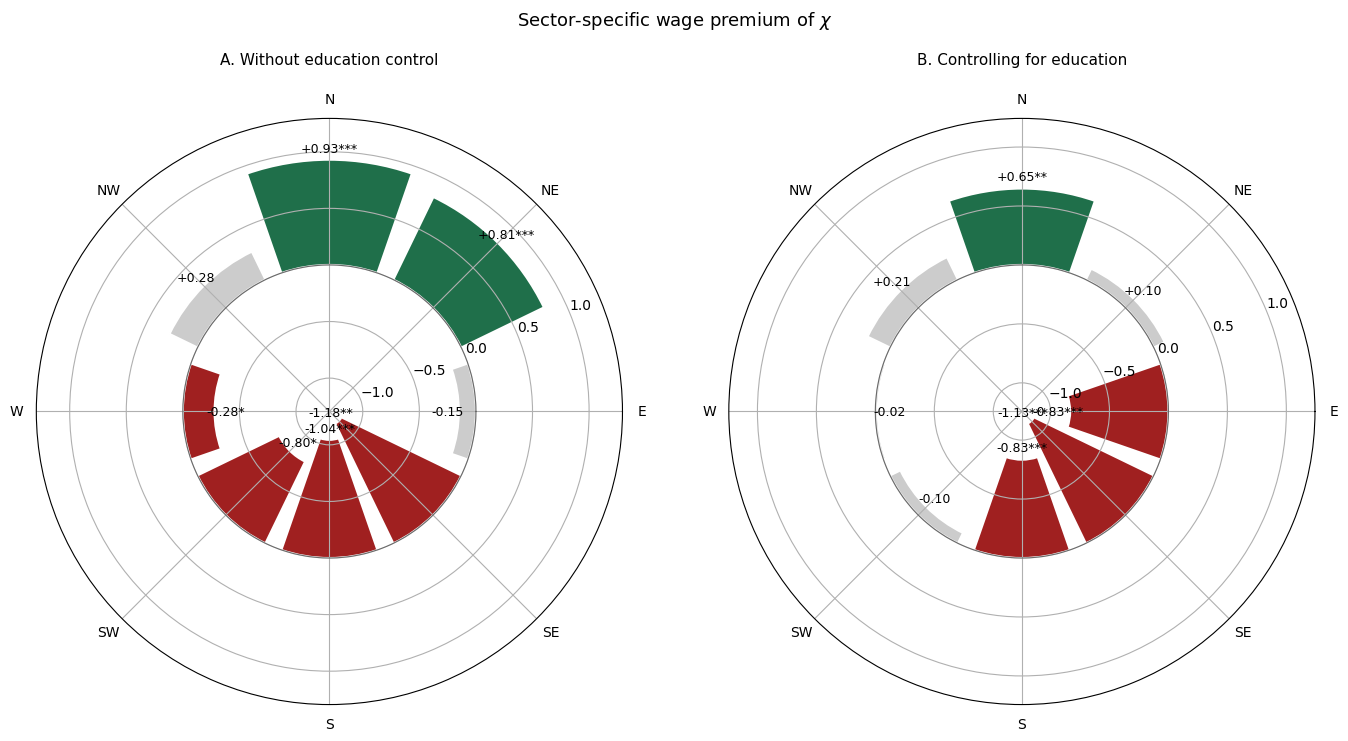

In [19]:
# Cell: Polar bar plot of beta_chi by sector
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sector_df = pd.read_csv(RP.exports / "mincer_chi_by_sector.csv")

# Two panels: unconditional and conditional
fig, axes = plt.subplots(1, 2, figsize=(14, 7),
                          subplot_kw={'projection': 'polar'})

for ax, beta_col, p_col, title in [
    (axes[0], 'beta_chi_unconditional', 'p_chi_unconditional',
     'A. Without education control'),
    (axes[1], 'beta_chi_conditional', 'p_chi_conditional',
     'B. Controlling for education'),
]:
    angles = np.radians(sector_df['center_deg'].to_numpy())
    betas = sector_df[beta_col].to_numpy()
    pvals = sector_df[p_col].to_numpy()
    
    # Color by sign and significance
    colors = []
    for b, p in zip(betas, pvals):
        if p > 0.05:
            colors.append('#cccccc')  # not significant
        elif b > 0:
            colors.append('#1f6f4a')  # positive: dark green
        else:
            colors.append('#a02020')  # negative: dark red
    
    # Width: 45 degrees per sector
    width = np.radians(45) * 0.85
    
    ax.bar(angles, betas, width=width, color=colors,
           edgecolor='white', linewidth=1.5)
    
    # Reference circle at zero
    theta_circle = np.linspace(0, 2*np.pi, 200)
    ax.plot(theta_circle, np.zeros_like(theta_circle), 'k-', lw=0.8, alpha=0.4)
    
    # Configure
    ax.set_theta_zero_location('E')
    ax.set_theta_direction(1)
    ax.set_title(title, fontsize=11, pad=20)
    
    # Set radial limits to encompass both positive and negative
    max_abs = max(abs(betas.min()), abs(betas.max()))
    ax.set_ylim(-max_abs * 1.1, max_abs * 1.1)
    
    # Label cardinal directions
    ax.set_xticks(np.radians([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(['E', 'NE', 'N', 'NW', 'W', 'SW', 'S', 'SE'])
    
    # Annotate beta values
    for ang, b, p in zip(angles, betas, pvals):
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        r_text = b + (0.1 if b >= 0 else -0.1)
        ax.text(ang, r_text, f'{b:+.2f}{sig}', 
                ha='center', va='center', fontsize=9)

fig.suptitle(r'Sector-specific wage premium of $\chi$', fontsize=13, y=1.02)
fig.tight_layout()

out_pdf = RP.figures / 'beta_chi_by_sector.pdf'
out_png = RP.figures / 'beta_chi_by_sector.png'
fig.savefig(out_pdf, dpi=300, bbox_inches='tight')
fig.savefig(out_png, dpi=300, bbox_inches='tight')
print(f"\nSaved: {out_pdf}")
print(f"Saved: {out_png}")

plt.show()

In [22]:
# Selectied occupations

selected = [
    "Physicians, Pathologists",
    "Biological Science Teachers, Postsecondary",
    "Chemical Engineers",
    "Software Developers",
    "Machinists",
    "Carpenters",
    "Lawyers",
    "Waiters and Waitresses",
    "Dishwashers",
]
cols = ["Title", "xi", "chi", "H_MEDIAN", "rle_mean"]
print(
    reg_df.merge(jobs[["onet_code", "Title"]], on="onet_code")
          .loc[lambda d: d["Title"].isin(selected), cols]
          .assign(xi_deg=lambda d: np.degrees(d["xi"]) % 360,
                  ln_wage=lambda d: np.log(d["H_MEDIAN"]))
          .sort_values("H_MEDIAN", ascending=False)
)

                      Title        xi       chi  H_MEDIAN  rle_mean  \
239                 Lawyers  0.092126  0.385092     70.08   10.7719   
102     Software Developers  1.309612  0.452267     63.59    5.8725   
127      Chemical Engineers  1.907640  0.520746     53.90    6.1740   
537              Carpenters  3.417826  0.421398     27.09    2.2055   
663              Machinists  2.854854  0.570705     24.44    2.5417   
410  Waiters and Waitresses  4.741102  0.486598     15.36    1.8025   
413             Dishwashers  4.162872  0.536904     15.00    1.5809   

         xi_deg   ln_wage  
239    5.278436  4.249637  
102   75.035246  4.152456  
127  109.299711  3.987130  
537  195.826999  3.299165  
663  163.571081  3.196221  
410  271.645152  2.731767  
413  238.514973  2.708050  


In [23]:
# === Cell 18: Cluster-based mediation analysis ==============================
# Replaces the global capability-intensity mediator (Cell 17) with substantive
# cluster intensities derived from the S1/S2/A1/A2 clustering in Section 4.2.1:
#   S1: Social/Cognitive skills (27 descriptors)
#   S2: Technical/Physical skills (8 descriptors)
#   A1: Social/Cognitive abilities (20 descriptors)
#   A2: Technical/Physical abilities (32 descriptors)
#
# For each occupation we compute its mean level within each cluster, then
# test whether these cluster intensities mediate the wage return to chi,
# separately by sector and globally.
import numpy as np
import pandas as pd
import statsmodels.api as sm

# ── Load inputs from Notebook 4 outputs ──────────────────────────────────────
# These files are produced by the capability notebook (Notebook 4).
membership_fp = RP.exports / "gradient_compass_clusters_membership.csv"
skills_long_fp = RP.exports / "skills_overlay_long.csv"
ability_long_fp = RP.exports / "abilities_overlay_long.csv"

try:
    membership = pd.read_csv(membership_fp)
    skills_long = pd.read_csv(skills_long_fp)
    ability_long = pd.read_csv(ability_long_fp)
    print(f"Loaded membership:       {len(membership)} descriptors")
    print(f"Loaded skills_long:      {skills_long.shape}")
    print(f"Loaded abilities_long:   {ability_long.shape}")
except FileNotFoundError as e:
    print(f"Missing file: {e}")
    print("Run Notebook 4 first and ensure it exports:")
    print("  - gradient_compass_clusters_membership.csv")
    print("  - skills_overlay_long.csv")
    print("  - abilities_overlay_long.csv")
    raise

# ── Map cluster_rank to cluster labels used in the paper ─────────────────────
# rank 1 = pole 1 (Social/Cognitive) -> S1 (skills) or A1 (abilities)
# rank 2 = pole 2 (Technical/Physical) -> S2 (skills) or A2 (abilities)
def cluster_label(row):
    prefix = "S" if row["label"] == "skill" else "A"
    return f"{prefix}{row['cluster_rank']}"

membership["cluster"] = membership.apply(cluster_label, axis=1)
print("\nCluster sizes:")
print(membership["cluster"].value_counts().reindex(["S1", "S2", "A1", "A2"]))

# ── Compute cluster intensity per occupation ─────────────────────────────────
def compute_cluster_intensity(long_df, membership_df, descriptor_col, label):
    """Mean descriptor level per (occupation, cluster) for a given label."""
    m = membership_df[membership_df["label"] == label][["name", "cluster"]]
    merged = long_df.merge(m, left_on=descriptor_col, right_on="name", how="inner")
    out = (
        merged.groupby(["onet_code", "cluster"])["value"]
        .mean()
        .unstack("cluster")
    )
    return out

skill_int = compute_cluster_intensity(skills_long, membership, "skill", "skill")
ability_int = compute_cluster_intensity(ability_long, membership, "ability", "ability")
cluster_int = skill_int.join(ability_int, how="inner").reset_index()
print(f"\nCluster intensities computed for {len(cluster_int)} occupations")
print(cluster_int.head(3))

# ── Merge into the existing regression dataset ───────────────────────────────
reg_df_clust = reg_df.merge(cluster_int, on="onet_code", how="inner")
print(f"\nRegression sample with cluster intensities: {len(reg_df_clust)}")

# ── Model A: chi + education only (per sector) ──────────────────────────────
# Model B: + cluster intensities S1, S2, A1, A2
def estimate_A(df_sec):
    if len(df_sec) < 15:
        return None
    X = sm.add_constant(df_sec[["chi", "rle_mean"]].astype(float))
    y = df_sec["ln_wage"].astype(float)
    return sm.OLS(y, X).fit(cov_type="HC3")

def estimate_B(df_sec):
    if len(df_sec) < 15:
        return None
    cols = ["chi", "rle_mean", "S1", "S2", "A1", "A2"]
    X = sm.add_constant(df_sec[cols].astype(float))
    y = df_sec["ln_wage"].astype(float)
    return sm.OLS(y, X).fit(cov_type="HC3")

rows = []
for sec_idx, sec_label in enumerate(sector_labels):
    df_sec = reg_df_clust.loc[reg_df_clust["sector_idx"] == sec_idx]
    n = len(df_sec)
    if n < 15:
        continue
    
    mA = estimate_A(df_sec)
    mB = estimate_B(df_sec)
    
    row = {
        "sector": sec_label,
        "n": n,
        "beta_chi_A": mA.params["chi"],
        "p_chi_A": mA.pvalues["chi"],
        "beta_chi_B": mB.params["chi"],
        "p_chi_B": mB.pvalues["chi"],
    }
    for c in ["S1", "S2", "A1", "A2"]:
        row[f"delta_{c}"] = mB.params.get(c, np.nan)
        row[f"p_{c}"] = mB.pvalues.get(c, np.nan)
    rows.append(row)

cluster_med_df = pd.DataFrame(rows)

# ── Print formatted table ────────────────────────────────────────────────────
def sig_stars(p):
    if not np.isfinite(p): return ""
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    if p < 0.10:  return "+"
    return ""

print("\n" + "═" * 95)
print("Sector-specific mediation by cluster intensities")
print("═" * 95)
print(f"{'Sector':<6} {'N':>4} {'β_χ (A)':>11} {'β_χ (B)':>11} "
      f"{'δ_S1':>10} {'δ_S2':>10} {'δ_A1':>10} {'δ_A2':>10}")
print("─" * 95)
for _, r in cluster_med_df.iterrows():
    print(
        f"{r['sector']:<6} {int(r['n']):>4} "
        f"{r['beta_chi_A']:>+8.3f}{sig_stars(r['p_chi_A']):<3} "
        f"{r['beta_chi_B']:>+8.3f}{sig_stars(r['p_chi_B']):<3} "
        f"{r['delta_S1']:>+7.3f}{sig_stars(r['p_S1']):<3} "
        f"{r['delta_S2']:>+7.3f}{sig_stars(r['p_S2']):<3} "
        f"{r['delta_A1']:>+7.3f}{sig_stars(r['p_A1']):<3} "
        f"{r['delta_A2']:>+7.3f}{sig_stars(r['p_A2']):<3}"
    )

# ── Global model for comparison ──────────────────────────────────────────────
print("\n" + "═" * 95)
print("Global model: ln(wage) ~ cos(ξ) + sin(ξ) + χ + rle_mean + S1 + S2 + A1 + A2")
print("═" * 95)
X_global = sm.add_constant(
    reg_df_clust[["cos_xi", "sin_xi", "chi", "rle_mean", "S1", "S2", "A1", "A2"]]
    .astype(float)
)
m_global = sm.OLS(reg_df_clust["ln_wage"], X_global).fit(cov_type="HC3")
print(m_global.summary())

# ── Export sector-level results ──────────────────────────────────────────────
out_csv = RP.exports / "mincer_mediation_cluster_intensity.csv"
cluster_med_df.to_csv(out_csv, index=False, float_format="%.6f")
print(f"\nSaved: {out_csv}")

Loaded membership:       87 descriptors
Loaded skills_long:      (30730, 6)
Loaded abilities_long:   (45656, 6)

Cluster sizes:
cluster
S1    27
S2     8
A1    20
A2    32
Name: count, dtype: int64

Cluster intensities computed for 878 occupations
cluster   onet_code        S1       S2      A1        A2
0        11-1011.00  4.186296  0.59375  4.2440  0.852187
1        11-1011.03  3.485556  0.57875  3.7180  0.656250
2        11-1021.00  3.272593  0.87375  3.4115  0.879062

Regression sample with cluster intensities: 785

═══════════════════════════════════════════════════════════════════════════════════════════════
Sector-specific mediation by cluster intensities
═══════════════════════════════════════════════════════════════════════════════════════════════
Sector    N     β_χ (A)     β_χ (B)       δ_S1       δ_S2       δ_A1       δ_A2
───────────────────────────────────────────────────────────────────────────────────────────────
E       125   -0.834***   -1.277***  +0.475***  -0.003   

In [24]:
# === Cell: χ vs cluster intensity correlations by sector ====================
# Tests how strongly chi correlates with each cluster intensity, globally
# and within each angular sector. This clarifies whether the mediation
# pattern in Cell 18 reflects substantive variation in capability use or
# mechanical co-variation between chi and intensity within direction.
from scipy.stats import spearmanr

print("═" * 80)
print(f"{'Sector':<8} {'N':>4} "
      f"{'ρ(χ,S1)':>10} {'ρ(χ,S2)':>10} "
      f"{'ρ(χ,A1)':>10} {'ρ(χ,A2)':>10}")
print("─" * 80)

# Global row
n_global = len(reg_df_clust)
row_global = {"sector": "GLOBAL", "n": n_global}
for c in ["S1", "S2", "A1", "A2"]:
    rho, _ = spearmanr(reg_df_clust["chi"], reg_df_clust[c])
    row_global[f"rho_{c}"] = rho

print(
    f"{'GLOBAL':<8} {n_global:>4} "
    f"{row_global['rho_S1']:>+10.3f} {row_global['rho_S2']:>+10.3f} "
    f"{row_global['rho_A1']:>+10.3f} {row_global['rho_A2']:>+10.3f}"
)
print("─" * 80)

# Per sector
rows = [row_global]
for sec_idx, sec_label in enumerate(sector_labels):
    df_sec = reg_df_clust.loc[reg_df_clust["sector_idx"] == sec_idx]
    n = len(df_sec)
    if n < 15:
        continue
    row = {"sector": sec_label, "n": n}
    for c in ["S1", "S2", "A1", "A2"]:
        rho, _ = spearmanr(df_sec["chi"], df_sec[c])
        row[f"rho_{c}"] = rho
    rows.append(row)
    print(
        f"{sec_label:<8} {n:>4} "
        f"{row['rho_S1']:>+10.3f} {row['rho_S2']:>+10.3f} "
        f"{row['rho_A1']:>+10.3f} {row['rho_A2']:>+10.3f}"
    )

corr_df = pd.DataFrame(rows)
out_csv = RP.exports / "chi_vs_cluster_intensity_correlations.csv"
corr_df.to_csv(out_csv, index=False, float_format="%.4f")
print(f"\nSaved: {out_csv}")

════════════════════════════════════════════════════════════════════════════════
Sector      N    ρ(χ,S1)    ρ(χ,S2)    ρ(χ,A1)    ρ(χ,A2)
────────────────────────────────────────────────────────────────────────────────
GLOBAL    785     -0.188     +0.300     -0.196     +0.240
────────────────────────────────────────────────────────────────────────────────
E         125     +0.340     -0.357     +0.258     -0.266
NE        101     +0.585     -0.219     +0.639     -0.284
N          92     +0.531     +0.062     +0.615     -0.327
NW         44     +0.084     +0.490     +0.176     +0.421
W         200     -0.468     +0.172     -0.475     +0.164
SW         67     -0.566     +0.083     -0.614     +0.102
S          78     -0.525     -0.304     -0.507     -0.142
SE         78     -0.078     -0.328     -0.143     -0.328

Saved: /home/joc/code/geometry-of-work/out/runs/embeddings__openai__text-embedding-3-large__d3072__year-2025__v30_1/exports/chi_vs_cluster_intensity_correlations.csv
